# Đáp án chi tiết - Tur4: Nhập và Lưu Trữ Dữ Liệu

Notebook này cung cấp **đáp án đầy đủ** cho các bài thực hành về đọc ghi và thu thập dữ liệu bằng Python (Pandas, Requests, v.v.).

# PHẦN I. ĐỌC VÀ LƯU DỮ LIỆU Ở ĐỊNH DẠNG VĂN BẢN

In [18]:
# from google.colab import drive

#kết nối Google Drive với môi trường Colab
# drive.mount('/content/drive')

#Hỗ trợ rút gọn đường dẫn, thuận tiện khi cần gọi tới các file nhiều lần trong chương trình.
# Nếu bạn chạy ở local, có thể đổi đường dẫn này thành thư mục chứa data.
# root_path = "/content/drive/MyDrive/"
root_path = ""  # Chạy ở môi trường local giả định data nằm cùng thư mục

## Bài 1.1: Đọc file asean_gdp_2024.csv, top 5 GDP cao nhất

In [19]:
import pandas as pd

# Đọc file CSV từ thư mục data có sẵn
df = pd.read_csv(root_path + "data/asean_gdp_2024.csv")

# Tự động nhận diện tên cột GDP để tránh KeyError do khác chuẩn tên cột
gdp_candidates = ["GDP (Billion USD)", "GDP (tỷ USD)", "GDP_USD_Billion", "GDP"]
gdp_col = next((c for c in gdp_candidates if c in df.columns), None)
if gdp_col is None:
    raise KeyError(f"Không tìm thấy cột GDP. Các cột hiện có: {list(df.columns)}")

# Sắp xếp giảm dần theo GDP và lấy 5 quốc gia đứng đầu
top5 = df.sort_values(by=gdp_col, ascending=False).head(5)

print("5 quốc gia ASEAN có GDP cao nhất năm 2024:")
print(top5)

# Giải thích: sort_values() sắp xếp cột chỉ định, ascending=False để sắp xếp từ lớn đến bé, head(5) lấy 5 dòng đầu.

5 quốc gia ASEAN có GDP cao nhất năm 2024:
       Country  Year  GDP_USD_Billion
2    Indonesia  2024           1465.0
8     Thailand  2024            610.8
6  Philippines  2024            560.4
9      Vietnam  2024            490.6
7    Singapore  2024            460.2


## Bài 1.2: Đọc file asean_gdp_2024.csv, top 5 GDP thấp nhất

In [20]:
# Đọc file CSV
df = pd.read_csv(root_path + "data/asean_gdp_2024.csv")

# Tự động nhận diện tên cột GDP để tránh KeyError do khác chuẩn tên cột
gdp_candidates = ["GDP (Billion USD)", "GDP (tỷ USD)", "GDP_USD_Billion", "GDP"]
gdp_col = next((c for c in gdp_candidates if c in df.columns), None)
if gdp_col is None:
    raise KeyError(f"Không tìm thấy cột GDP. Các cột hiện có: {list(df.columns)}")

# Sắp xếp tăng dần theo GDP và lấy 5 quốc gia
bottom5 = df.sort_values(by=gdp_col, ascending=True).head(5)

print("5 quốc gia ASEAN có GDP thấp nhất năm 2024:")
print(bottom5)

# Giải thích: Mặc định ascending=True nên sort_values() sắp xếp từ bé đến lớn.

5 quốc gia ASEAN có GDP thấp nhất năm 2024:
    Country  Year  GDP_USD_Billion
0    Brunei  2024             16.5
3      Laos  2024             24.5
1  Cambodia  2024             38.2
5   Myanmar  2024             96.7
4  Malaysia  2024            420.3


## Bài 1.3: Đổi tên cột sang Tiếng Việt

In [21]:
# Lệnh đọc file
df = pd.read_csv(root_path + "data/asean_gdp_2024.csv")

# Đổi tên cột sang Tiếng Việt theo nhiều khả năng tên cột đầu vào
rename_map = {}
if "Country" in df.columns:
    rename_map["Country"] = "Quốc gia"
if "Year" in df.columns:
    rename_map["Year"] = "Năm"
if "GDP (Billion USD)" in df.columns:
    rename_map["GDP (Billion USD)"] = "GDP (tỷ USD)"
elif "GDP" in df.columns:
    rename_map["GDP"] = "GDP (tỷ USD)"

# Giữ nguyên cột đã là tiếng Việt (nếu có)
df_renamed = df.rename(columns=rename_map)

print("Thông tin GDP của 10 quốc gia ASEAN (năm 2024):")
print(df_renamed)

# Giải thích: rename() dùng dictionary map tên cũ -> tên mới; làm linh hoạt để không lỗi khi dữ liệu đổi header.

Thông tin GDP của 10 quốc gia ASEAN (năm 2024):
      Quốc gia   Năm  GDP_USD_Billion
0       Brunei  2024             16.5
1     Cambodia  2024             38.2
2    Indonesia  2024           1465.0
3         Laos  2024             24.5
4     Malaysia  2024            420.3
5      Myanmar  2024             96.7
6  Philippines  2024            560.4
7    Singapore  2024            460.2
8     Thailand  2024            610.8
9      Vietnam  2024            490.6


## Bài 1.4: Đọc dữ liệu tăng trưởng GDP và đổi tên cột sang Tiếng Anh

In [22]:
# Lệnh đọc file có sẵn
df_growth = pd.read_csv(root_path + "data/asean_growth_wide_2015_2024.csv")

# Cách 1: dùng hàm rename với vòng lặp hoặc dict comprehension
new_columns = {"Quốc gia": "Country"}
for col in df_growth.columns:
    if "Tăng trưởng" in col:
        year = col.split(" ")[2]
        new_columns[col] = f"Growth rate {year} (%)"

df_growth_eng = df_growth.rename(columns=new_columns)

print("GDP Growth of ASEAN Countries:")
print(df_growth_eng.head())

# Giải thích: Ta lặp qua tên cột, dùng string split để lấy năm và gán tên mới tiếng Anh.

GDP Growth of ASEAN Countries:
       Country  Growth rate 2015 (%)  Growth rate 2016 (%)  \
0     Việt Nam              7.727560              4.876393   
1    Indonesia              5.330782              4.375888   
2     Thái Lan              2.414675              2.587559   
3     Malaysia              7.298791              5.383341   
4  Philippines              2.275778              7.507076   

   Growth rate 2024 (%)  
0              6.398404  
1              5.727601  
2              6.521047  
3              4.055470  
4              5.416458  


## Bài 1.5: File Excel, điền giá trị thiếu bằng 0 và lưu file mới

In [23]:
# Đường dẫn file Excel
file_path_in = root_path + "data/VN_Economic_Indicators_2024_with_missing.xlsx"
file_path_out = root_path + "data/VN_Economic_Indicators_2024_filled.xlsx"

# Đọc dữ liệu từ sheet có tên "Vietnam 2024 Indicators"
df_excel = pd.read_excel(file_path_in, sheet_name="Vietnam 2024 Indicators")

# Thay thế toàn bộ giá trị NaN bằng 0 bằng cách sử dụng hàm fillna
df_excel.fillna(0, inplace=True)

# Hiển thị dữ liệu sau khi xử lý
print("Dữ liệu sau khi thay thế NaN bằng 0:")
print(df_excel)

# Lưu dữ liệu ra file Excel mới
df_excel.to_excel(file_path_out, index=False)
print(f"\nFile dữ liệu đã được lưu tại: {file_path_out}")

# Giải thích:
# - pd.read_excel với tham số sheet_name.
# - fillna(0) điền tất cả ô trống bằng 0. inplace=True sửa trực tiếp trên DataFrame.
# - to_excel() ghi dataframe thành file Excel.

Dữ liệu sau khi thay thế NaN bằng 0:
                       Chỉ số  Tháng 1  Tháng 2  Tháng 3  Tháng 4
0  CPI (Consumer Price Index)    104.5    104.8      0.0    105.2
1             Thất nghiệp (%)      2.4      2.5      2.6      2.4
2  PPI (Producer Price Index)    107.2    107.5    107.8      0.0

File dữ liệu đã được lưu tại: data/VN_Economic_Indicators_2024_filled.xlsx


## Bài 1.6: Đọc file Excel, lấy dữ liệu CPI, chuyển wide sang long

In [24]:
import pandas as pd

# Đọc file Excel
df_full = pd.read_excel(root_path + "data/VN_Economic_Indicators_2024_full.xlsx")

# Chọn hàng chứa CPI (chứa chữ CPI)
df_cpi = df_full[df_full['Chỉ số'].str.contains('CPI')].copy()

# Bỏ cột "Chỉ số" vì chỉ lấy theo tháng
df_cpi = df_cpi.drop(columns=['Chỉ số'])

# Chuyển từ wide -> long: mỗi tháng thành 1 dòng (dùng melt)
# Hoặc dùng transpose (T) vì dữ liệu chỉ còn 1 dòng
df_cpi_long = df_cpi.T.reset_index()
df_cpi_long.columns = ['Tháng', 'Chỉ số CPI']

# Hiển thị kết quả
print("Dữ liệu CPI (Wide -> Long):")
print(df_cpi_long)

# Giải thích: Chuyển vị .T biến cột thành hàng, biến hàng thành cột, 
# reset_index() để lấy tên cột ban đầu làm một cột mới tên là 'Tháng'.

Dữ liệu CPI (Wide -> Long):
     Tháng  Chỉ số CPI
0  Tháng 1       104.5
1  Tháng 2       104.8
2  Tháng 3         NaN
3  Tháng 4       105.2


## Bài 1.7: Đọc file Excel, Thất nghiệp và PPI, wide sang long

In [25]:
# Đường dẫn file Excel
df_full = pd.read_excel(root_path + "data/VN_Economic_Indicators_2024_full.xlsx")

# Lấy 2 dòng: Thất nghiệp và PPI
df_unemp = df_full[df_full['Chỉ số'].str.contains('Thất nghiệp')].drop(columns=['Chỉ số']).T.reset_index()
df_ppi = df_full[df_full['Chỉ số'].str.contains('PPI')].drop(columns=['Chỉ số']).T.reset_index()

df_unemp.columns = ['Tháng', 'Thất nghiệp']
df_ppi.columns = ['Tháng', 'PPI']

# Gộp 2 bảng theo cột "Tháng"
df_merged = pd.merge(df_unemp, df_ppi, on='Tháng')

# Hiển thị kết quả
print("Thông tin Thất nghiệp và PPI Việt Nam năm 2024:")
print(df_merged)

# Giải thích: pd.merge(df1, df2, on='Tháng') ghép hai bảng với nhau dựa trên cột chung là 'Tháng'.

Thông tin Thất nghiệp và PPI Việt Nam năm 2024:
     Tháng  Thất nghiệp    PPI
0  Tháng 1          2.4  107.2
1  Tháng 2          2.5  107.5
2  Tháng 3          2.6  107.8
3  Tháng 4          2.4    NaN


## Bài 1.8: Thất nghiệp, PPI và CPI -> gộp -> Excel mới

In [26]:
import pandas as pd

# Đọc file Excel gốc
df_full = pd.read_excel(root_path + "data/VN_Economic_Indicators_2024_full.xlsx")

# Dùng hàm melt để chuyển đổi toàn bộ DataFrame thành dạng long
df_melted = df_full.melt(id_vars=["Chỉ số"], var_name="Tháng", value_name="Giá trị")

# Dùng hàm pivot để xoay lại: Cột "Chỉ số" biến thành các cột riêng biệt
df_pivot = df_melted.pivot(index="Tháng", columns="Chỉ số", values="Giá trị").reset_index()

# Đổi tên cột cho đẹp
df_pivot.rename(columns={
    'CPI (Consumer Price Index)': 'CPI',
    'PPI (Producer Price Index)': 'PPI',
    'Thất nghiệp (%)': 'Thất nghiệp'
}, inplace=True)

# Đảm bảo thứ tự cột theo yêu cầu
df_final = df_pivot[['Tháng', 'CPI', 'Thất nghiệp', 'PPI']]

# Hiển thị dữ liệu
print("Thông tin CPI, Thất nghiệp và PPI Việt Nam năm 2024:")
print(df_final)

# Ghi dữ liệu ra file Excel mới
out_path = root_path + "data/VN_Economic_Indicators_2024_selected.xlsx"
df_final.to_excel(out_path, index=False)
print(f"\nDữ liệu đã được lưu vào file: {out_path}")

# Giải thích: Thay vì chuyển đổi thủ công từng hàng, melt() biến từ dạng wide sang long. 
# Sau đó pivot() có thể xoay lại theo ý muốn.

Thông tin CPI, Thất nghiệp và PPI Việt Nam năm 2024:
Chỉ số    Tháng    CPI  Thất nghiệp    PPI
0       Tháng 1  104.5          2.4  107.2
1       Tháng 2  104.8          2.5  107.5
2       Tháng 3    NaN          2.6  107.8
3       Tháng 4  105.2          2.4    NaN

Dữ liệu đã được lưu vào file: data/VN_Economic_Indicators_2024_selected.xlsx


## Bài 1.9: Đọc dữ liệu JSON chứng khoán

In [27]:
import pandas as pd

# Đường dẫn tới file JSON
json_file = root_path + "data/vn10_stocks.json"

# Đọc file JSON và chuyển thành DataFrame
df_stocks = pd.read_json(json_file)

# Hiển thị toàn bộ thông tin
print("Dữ liệu chứng khoán:")
print(df_stocks)

# Giải thích: Hàm pd.read_json() đọc trực tiếp nội dung JSON thành DataFrame.

Dữ liệu chứng khoán:
  ticker      company  price    pe   pb
0    VCB  Vietcombank  94000  12.8  3.0
1    VIC     Vingroup  47000  35.0  3.8
2    VHM     Vinhomes  48000   9.5  1.8


# PHẦN II. THU THẬP DỮ LIỆU WEB

## Bài 2.1: Tải các bảng từ Wikipedia ASEAN, in nội dung bảng 6

In [28]:
import pandas as pd
import requests

url = "https://en.wikipedia.org/wiki/ASEAN"
# Tạo header giả lập như trình duyệt thật
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/119.0.0.0 Safari/537.36"
}

# Dùng requests để tải HTML
response = requests.get(url, headers=headers)
response.raise_for_status()  # nếu lỗi HTTP sẽ báo ngay

# Dùng read_html lấy tất cả bảng bằng string/StringIO tránh lỗi DeprecationWarning
from io import StringIO
tables = pd.read_html(StringIO(response.text))

print(f"Số lượng bảng đọc được từ {url}: {len(tables)}\n")

# Lấy bảng số 6 (chỉ số 6 tương ứng với bảng thứ 7 trên web, thông thường là bảng đô thị đông dân)
# Lưu ý: Cấu trúc HTML Wikipedia có thể thay đổi. Ở đây ta giả sử tables[6] là đúng mục tiêu
df_table6 = tables[6]
print(df_table6.head())

# Giải thích: pd.read_html phân tích mã HTML và tìm các thẻ <table> chuyển thành danh sách DataFrame.

Số lượng bảng đọc được từ https://en.wikipedia.org/wiki/ASEAN: 43

  Country[132] Population (millions)             GDP Nominal                 \
  Country[132] Population (millions)         millions of USD per capita USD   
0    Indonesia               279.965  1,430,000 (2025f)[133]           5030   
1    Singapore                 5.938    564,770 (2025f)[134]          92930   
2     Thailand                65.975    546,220 (2025f)[135]           7770   
3  Philippines               114.161    497,500 (2025f)[136]           4350   
4      Vietnam               100.770    490,970 (2025f)[137]           4810   

         GDP (PPP)                  
  millions of Int$ per capita Int$  
0          5010000           17610  
1           952640          156760  
2          1850000           26320  
3          1480000           12920  
4          1790000           17689  


## Bài 2.2: Lọc bỏ cột, đổi tên tiếng Việt

In [29]:
# Tránh lỗi do Wikipedia thay đổi cấu trúc bảng (có thể MultiIndex hoặc khác vị trí)
def flatten_cols(df):
    if isinstance(df.columns, pd.MultiIndex):
        df = df.copy()
        df.columns = [" ".join([str(x) for x in tup if str(x) != "nan"]).strip() for tup in df.columns]
    else:
        df = df.copy()
        df.columns = [str(c) for c in df.columns]
    return df

candidate = None
for tbl in tables:
    t = flatten_cols(tbl)
    cols_lower = [c.lower() for c in t.columns]
    # Ưu tiên bảng đô thị (có Core city/Metropolitan area)
    if any("core city" in c for c in cols_lower) or any("metropolitan" in c for c in cols_lower):
        candidate = t
        break

# Nếu không tìm thấy đúng bảng đô thị, fallback về bảng có Country + Population
if candidate is None:
    for tbl in tables:
        t = flatten_cols(tbl)
        cols_lower = [c.lower() for c in t.columns]
        if any("country" in c for c in cols_lower) and any("population" in c for c in cols_lower):
            candidate = t
            break

if candidate is None:
    raise ValueError("Không tìm thấy bảng phù hợp trong danh sách tables.")

df_table6 = candidate.copy()

# Xóa các cột không cần nếu có
drop_keywords = ["metropolitan area", "census year"]
cols_to_drop = [c for c in df_table6.columns if any(k in c.lower() for k in drop_keywords)]
if cols_to_drop:
    df_table6 = df_table6.drop(columns=cols_to_drop)

# Đổi tên cột sang Tiếng Việt theo từ khóa
rename_map = {}
for c in df_table6.columns:
    cl = c.lower()
    if "core city" in cl or "city" in cl:
        rename_map[c] = "Thành phố trung tâm"
    elif "population" in cl:
        rename_map[c] = "Dân số"
    elif "area" in cl and "km" in cl:
        rename_map[c] = "Diện tích (km²)"
    elif "country" in cl:
        rename_map[c] = "Quốc gia"

df_cleaned = df_table6.rename(columns=rename_map)

# Loại cột trùng tên do MultiIndex phẳng hóa có thể tạo tên lặp
if df_cleaned.columns.duplicated().any():
    df_cleaned = df_cleaned.loc[:, ~df_cleaned.columns.duplicated()]

print(df_cleaned.head())

# Giải thích: ta tìm bảng theo từ khóa và đổi tên cột linh hoạt để không bị phụ thuộc vào cấu trúc HTML cố định.

   Dân số                 Thành phố trung tâm
0       1                     Greater Jakarta
1       2                 Greater Manila Area
2       3  Ho Chi Minh City metropolitan area
3       4                Hanoi Capital Region
4       5         Bangkok Metropolitan Region


## Bài 2.3: In ra 5 thành phố đông dân nhất

In [30]:
# Sắp xếp dân số giảm dần và lấy 5 phần tử đầu
pop_col = "Dân số" if "Dân số" in df_cleaned.columns else next((c for c in df_cleaned.columns if "population" in c.lower()), None)
if pop_col is None:
    raise KeyError(f"Không tìm thấy cột dân số. Các cột hiện có: {list(df_cleaned.columns)}")

# Chuẩn hóa dân số về số (loại dấu phẩy, chú thích dạng [123], ...)
pop_series = (
    df_cleaned[pop_col]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace(r"\[.*?\]", "", regex=True)
    .str.extract(r"([0-9]+\.?[0-9]*)", expand=False)
)
df_cleaned["Dân số"] = pd.to_numeric(pop_series, errors="coerce")

top5_cities = df_cleaned.sort_values(by="Dân số", ascending=False).head(5)

print("5 thành phố đông dân nhất Đông Nam Á:")
print(top5_cities)

# Giải thích: xử lý chuỗi dân số trước khi sort để tránh lỗi khi dữ liệu chứa ký tự không phải số.

5 thành phố đông dân nhất Đông Nam Á:
   Dân số         Thành phố trung tâm
9      10  Semarang metropolitan area
8       9               Yangon Region
7       8                Klang Valley
6       7             Greater Bandung
5       6            Greater Surabaya


## Bài 2.4: Biểu đồ tròn dân số

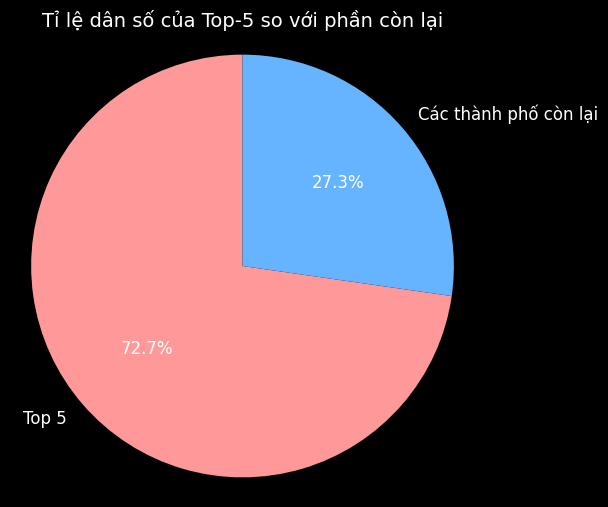

In [31]:
import matplotlib.pyplot as plt

# Đảm bảo có cột Dân số dạng số (được chuẩn hóa từ bài 2.3)
if "Dân số" not in df_cleaned.columns:
    raise KeyError("Chưa có cột 'Dân số'. Hãy chạy lại Bài 2.3 trước.")

# Tính tổng dân số các thành phố top5
top5_pop = top5_cities["Dân số"].sum()

# Tính tổng dân số các thành phố còn lại
other_pop = df_cleaned["Dân số"].sum() - top5_pop

# Chuẩn bị dữ liệu cho biểu đồ tròn
sizes = [top5_pop, other_pop]
labels = ["Top 5", "Các thành phố còn lại"]
colors = ["#ff9999", "#66b3ff"]

# Vẽ biểu đồ tròn
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90, textprops={"fontsize": 12})
plt.title("Tỉ lệ dân số của Top-5 so với phần còn lại", fontsize=14)
plt.axis("equal")  # Để vẽ thành hình tròn
plt.show()

# Giải thích:
# - Tổng dân số Top 5 tính bằng .sum().
# - Phần còn lại là tổng cả bảng trừ đi tổng Top 5.
# - plt.pie() dùng để vẽ biểu đồ tròn.

# PHẦN III. TƯƠNG TÁC VỚI API WEB

## Bài 3.1: API Users - Lấy id, name, username, email

In [32]:
import requests
import pandas as pd

# Gửi request đến API
url_api = "https://jsonplaceholder.typicode.com/users"
response_api = requests.get(url_api)
data_json = response_api.json()

# Chuyển dữ liệu JSON thành DataFrame
df_api = pd.DataFrame(data_json)

# Hiển thị cột id, name, username, email
df_api_selected = df_api[['id', 'name', 'username', 'email']]
print("Users:")
print(df_api_selected)

# Giải thích: requests.get() gọi API, .json() chuyển từ chuỗi JSON sang list dict. 
# pd.DataFrame đọc list dict tự động chuyển thành bảng.

Users:
   id                      name          username                      email
0   1             Leanne Graham              Bret          Sincere@april.biz
1   2              Ervin Howell         Antonette          Shanna@melissa.tv
2   3          Clementine Bauch          Samantha         Nathan@yesenia.net
3   4          Patricia Lebsack          Karianne  Julianne.OConner@kory.org
4   5          Chelsey Dietrich            Kamren   Lucio_Hettinger@annie.ca
5   6      Mrs. Dennis Schulist  Leopoldo_Corkery    Karley_Dach@jasper.info
6   7           Kurtis Weissnat      Elwyn.Skiles     Telly.Hoeger@billy.biz
7   8  Nicholas Runolfsdottir V     Maxime_Nienow       Sherwood@rosamond.me
8   9           Glenna Reichert          Delphine    Chaim_McDermott@dana.io
9  10        Clementina DuBuque    Moriah.Stanton     Rey.Padberg@karina.biz


## Bài 3.2: API Users - Lấy thông tin có cấu trúc lồng nhau (address)

In [33]:
import requests
import pandas as pd

# Lấy dữ liệu từ API
url_api = "https://jsonplaceholder.typicode.com/users"
response_api = requests.get(url_api)
data_json = response_api.json()

# Trích xuất thông tin cần thiết: name, username, street, city
# Ta dùng list comprehension để duyệt qua từng user. 
# street và city nằm bên trong key 'address'
extracted_data = []
for user in data_json:
    extracted_data.append({
        'name': user.get('name'),
        'username': user.get('username'),
        'street': user.get('address', {}).get('street'),
        'city': user.get('address', {}).get('city')
    })

# Đưa vào DataFrame
df_nested = pd.DataFrame(extracted_data)

# Hiển thị
print("Users (name, username, street, city):")
print(df_nested)

# Giải thích:
# - Vì JSON trả về cấu trúc lồng nhau (`address` là một dictionary bên trong), 
# nên ta không thể đọc thẳng bằng `pd.DataFrame()` mà phải trích xuất thủ công hoặc dùng `pd.json_normalize()`.

Users (name, username, street, city):
                       name          username             street  \
0             Leanne Graham              Bret        Kulas Light   
1              Ervin Howell         Antonette      Victor Plains   
2          Clementine Bauch          Samantha  Douglas Extension   
3          Patricia Lebsack          Karianne        Hoeger Mall   
4          Chelsey Dietrich            Kamren       Skiles Walks   
5      Mrs. Dennis Schulist  Leopoldo_Corkery  Norberto Crossing   
6           Kurtis Weissnat      Elwyn.Skiles          Rex Trail   
7  Nicholas Runolfsdottir V     Maxime_Nienow   Ellsworth Summit   
8           Glenna Reichert          Delphine         Dayna Park   
9        Clementina DuBuque    Moriah.Stanton    Kattie Turnpike   

             city  
0     Gwenborough  
1     Wisokyburgh  
2   McKenziehaven  
3     South Elvis  
4      Roscoeview  
5   South Christy  
6       Howemouth  
7       Aliyaview  
8  Bartholomebury  
9     Lebsack